# Compatbilização das malhas censitárias de 2010 e 2022 para o Distrito Federal

In [1]:
from utils import *

In [2]:
BASENAME = '2010-2022-DF-assessed' # Nome da compatibilização
NAME_C1 = 'DF_2010' # Nome da primeira malha censitária
NAME_C2 = 'DF_2022' # Nome da segunda malha censitária
location = 'DF'

## 1. Configuração das malhas

In [4]:
# Importação
malha_2010 = gpd.read_parquet(f'malhas/{NAME_C1}.parquet')
malha_2022 = gpd.read_parquet(f'malhas/{NAME_C2}.parquet')

## 2. Criação do grafo de compatibilização

In [5]:
G_compat = compatibility_graph(malha_2010, malha_2022)

c:\Users\Pedro\anaconda3\envs\geo\Lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 22672 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [6]:
G_compat.compatManutencao()
G_compat.compatDivisao(threshold=0.8)

# Aplica séries de buffers
for b in [-20, -10]:
    G_compat.compatSobreposicao(buffer=b)

# Sobreposição de isolados restantes
G_compat.compatSobreposicao(buffer=0, use_all=True)

c:\Users\Pedro\anaconda3\envs\geo\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\Pedro\anaconda3\envs\geo\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\Pedro\anaconda3\envs\geo\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

## 3. Comparação com malha oficial

In [7]:
# Criação do grafo verdadeiro com dados do IBGE
df_comp_ibge = pd.read_excel('ibge/Historico_formacao_Setores_Censitarios_2010_2022.xlsx')

nodesA = [int(i[2:]) for i in G_compat.nodes() if i.startswith('A')]
nodesB = [int(i[2:]) for i in G_compat.nodes() if i.startswith('B')]
ibge_2010_2022 = df_comp_ibge[['GEOCODIGO_2022_DIVULGAÇÃO','GEOCODIGO_2010']]
ibge_2010_2022 = ibge_2010_2022.query('GEOCODIGO_2022_DIVULGAÇÃO in @nodesB | GEOCODIGO_2010 in @nodesA')

truth_graph = nx.Graph()

# Adiciona nós existentes
truth_graph.add_nodes_from(G_compat.nodes())

# Adiciona arestas verdadeiras
for _, r in ibge_2010_2022.iterrows():
    truth_graph.add_edge(f"A.{r['GEOCODIGO_2010']}", f"B.{r['GEOCODIGO_2022_DIVULGAÇÃO']}")

# Remove nós excedentes
exceeding_nodes = [i for i in truth_graph.nodes() if i not in G_compat.nodes()]
truth_graph.remove_nodes_from(exceeding_nodes)

In [8]:
G_compat.assessEdges(ground_truth_graph=truth_graph)

## 4. Exportação dos resultados

In [9]:
G_compat.exportCompatFiles(BASENAME, NAME_C1, NAME_C2)

In [10]:
G_compat.reportCompat(file=f'malhas/{BASENAME}_report')

{'parametros': {'razão A/P': 0.2,
  'Limite base de sobreposicao (L)': [0.8],
  'Buffers': [{'buffer': -20, 'use_all': False},
   {'buffer': -10, 'use_all': False},
   {'buffer': 0, 'use_all': True}]},
 'malhas': {'Setores C1': 4454, 'Setores C2': 5418},
 'correspondencias': {'Correspondências totais': {'n': 5683, 'pct': 1},
  '': {'n': 21, 'pct': 0.003695231391870491},
  'Divisão': {'n': 1788, 'pct': 0.3146225585078304},
  'Manutenção': {'n': 3062, 'pct': 0.5387999296146402},
  'Manutenção desassociada': {'n': 7, 'pct': 0.0012317437972901636},
  'Sobreposição (-10m)': {'n': 12, 'pct': 0.0021115607953545662},
  'Sobreposição (-20m)': {'n': 790, 'pct': 0.1390110856941756},
  'Sobreposição (0m)': {'n': 3, 'pct': 0.0005278901988386416}},
 'operacoes': {'Operações totais': {'n': 4269, 'pct': 1},
  '1:1': {'n': 3841, 'pct': 0.8997423284141485},
  '1:n': {'n': 343, 'pct': 0.08034668540641836},
  'm:n': {'n': 62, 'pct': 0.014523307566174749},
  'n:1': {'n': 23, 'pct': 0.0053876786132583745}},

In [11]:
G_compat.assess_df['assessment'].unique()

array(['true positive', 'false positive', 'false negative'], dtype=object)

## 5. Testes com variação de parâmetros

In [12]:
for r in range(1,21):
    apr = round(0.1*r,2)
    G_compat.reset(ap_ratio=apr)
    G_compat.compatManutencao()
    G_compat.compatDivisao(threshold=0.8)
    # Aplica séries de buffers
    for b in [-20, -10]:
        G_compat.compatSobreposicao(buffer=b)
    # Sobreposição de isolados restantes
    G_compat.compatSobreposicao(buffer=0, use_all=True)

    G_compat.assessEdges(ground_truth_graph=truth_graph)

    G_compat.exportCompatFiles(BASENAME, NAME_C1, NAME_C2, save_files=False)
    G_compat.reportCompat(file=f'malhas/parametros/{BASENAME}_apr{str(apr).replace(".",",")}_report')

c:\Users\Pedro\anaconda3\envs\geo\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\Pedro\anaconda3\envs\geo\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\Pedro\anaconda3\envs\geo\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

In [13]:
for r in range(1,11):
    ts = round(0.1 * r,2)
    G_compat.reset()
    G_compat.compatManutencao()
    G_compat.compatDivisao(threshold=ts)
    # Aplica séries de buffers
    for b in [-20, -10]:
        G_compat.compatSobreposicao(buffer=b)
    # Sobreposição de isolados restantes
    G_compat.compatSobreposicao(buffer=0, use_all=True)

    G_compat.assessEdges(ground_truth_graph=truth_graph)

    G_compat.exportCompatFiles(BASENAME, NAME_C1, NAME_C2, save_files=False)
    G_compat.reportCompat(file=f'malhas/parametros/{BASENAME}_lmin{str(ts).replace(".",",")}_report.json')

c:\Users\Pedro\anaconda3\envs\geo\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\Pedro\anaconda3\envs\geo\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\Pedro\anaconda3\envs\geo\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

In [54]:
import json

In [ ]:
ap_files = [f'malhas/parametros/{i}' for i in os.listdir('malhas/parametros') if f'{BASENAME}_apr' in i]
datalist = []
for file in ap_files:
    with open(file, 'r') as f:
        datalist.append(json.load(f))

d = [{'razão A/P': x['parametros']['razão A/P']} for x in datalist]
d = [{**i, **j} for i,j in zip(d,[{k:v['n'] for k,v in x['metricas'].items()} for x in datalist])]
#d = [{**i, **j} for i,j in zip(d,[{k:v['n'] for k,v in x['correspondencias'].items()} for x in datalist])]

df_apr = pd.DataFrame(d)

d = [{'razão A/P': x['parametros']['razão A/P']} for x in datalist]
d = [{**i, **j} for i,j in zip(d,[{k:v for k,v in x['avaliacao'].items()} for x in datalist])]
df_apr = df_apr.merge(pd.DataFrame(d)[['razão A/P', 'recall', 'precision', 'f1_score']], on='razão A/P', how='left')
for c in ['recall', 'precision', 'f1_score']:
    df_apr[c] = df_apr[c]*1000

In [ ]:
ap_files = [f'malhas/parametros/{i}' for i in os.listdir('malhas/parametros') if f'{BASENAME}_lmin' in i]
datalist = []
for file in ap_files:
    with open(file, 'r') as f:
        datalist.append(json.load(f))

d = [{'Lmin': x['parametros']['Limite base de sobreposicao (L)'][0]} for x in datalist]
d = [{**i, **j} for i,j in zip(d,[{k:v['n'] for k,v in x['metricas'].items()} for x in datalist])]
#d = [{**i, **j} for i,j in zip(d,[{k:v['n'] for k,v in x['correspondencias'].items()} for x in datalist])]

df_lmin = pd.DataFrame(d)

d = [{'Lmin': x['parametros']['Limite base de sobreposicao (L)'][0]} for x in datalist]
d = [{**i, **j} for i,j in zip(d,[{k:v for k,v in x['avaliacao'].items()} for x in datalist])]
df_lmin = df_lmin.merge(pd.DataFrame(d)[['Lmin', 'recall', 'precision', 'f1_score']], on='Lmin', how='left')
for c in ['recall', 'precision', 'f1_score']:
    df_lmin[c] = df_lmin[c]*1000

C:\Users\Pedro\AppData\Local\Temp\ipykernel_30548\719382198.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].yaxis.set_ticklabels([t for t in ax[i].yaxis.get_ticklabels()])
C:\Users\Pedro\AppData\Local\Temp\ipykernel_30548\719382198.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].yaxis.set_ticklabels([t for t in ax[i].yaxis.get_ticklabels()])
C:\Users\Pedro\AppData\Local\Temp\ipykernel_30548\719382198.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].yaxis.set_ticklabels([t for t in ax[i].yaxis.get_ticklabels()])
C:\Users\Pedro\AppData\Local\Temp\ipykernel_30548\719382198.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax

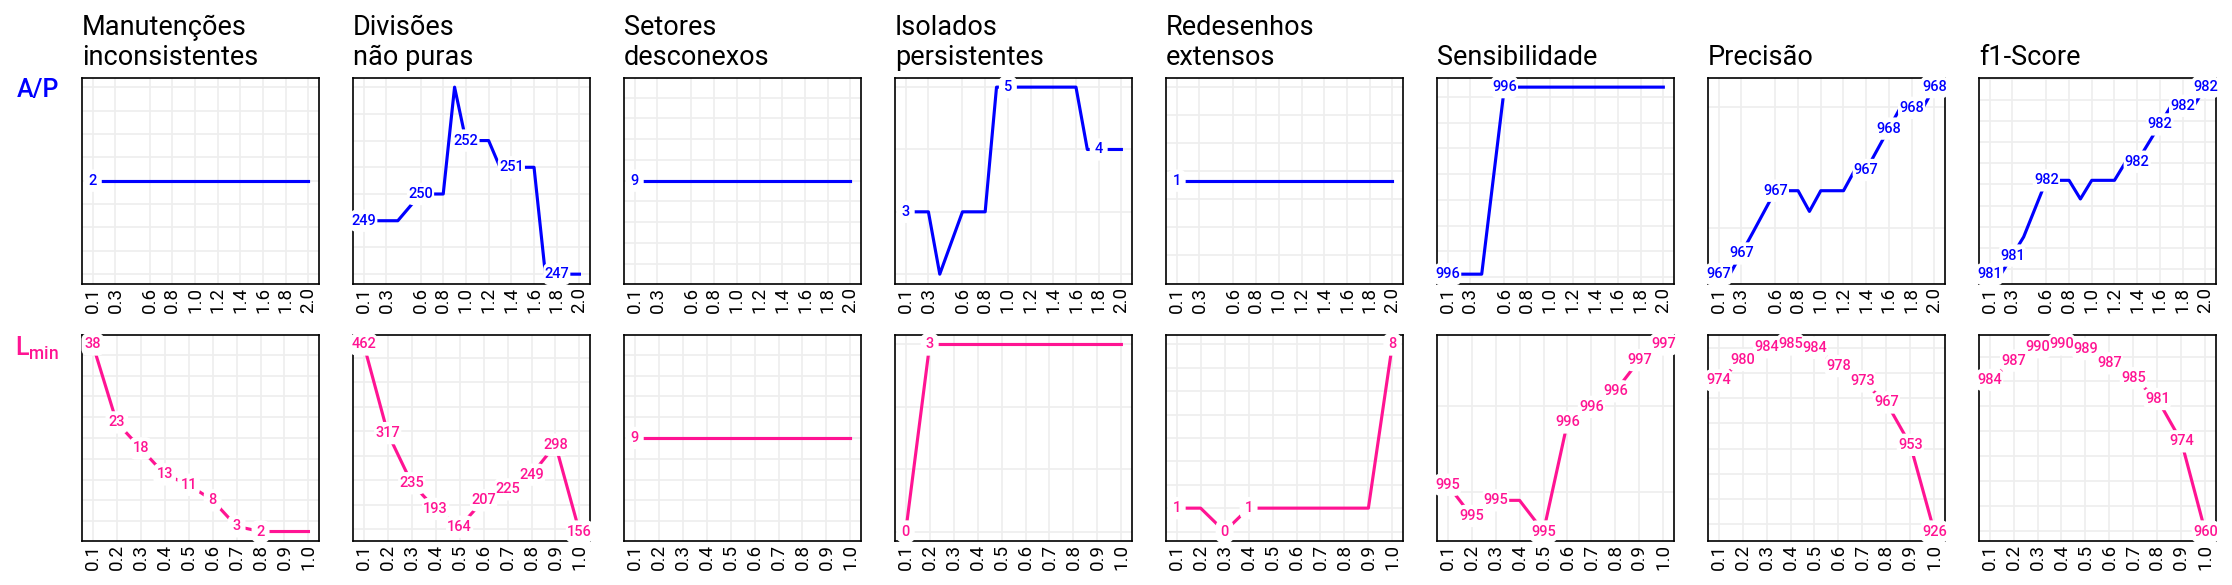

In [57]:
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
params = {'mathtext.default': 'regular' , 'font.family':'Roboto'} 
plt.rcParams.update(params)
import seaborn as sns

labels = {
    'Manutencoes inconsistentes':'Manutenções\ninconsistentes',
    'Divisoes nao puras':'Divisões\nnão puras',
    'Setores desconexos':'Setores\ndesconexos',
    'Isolados persistentes':'Isolados\npersistentes',
    'Redesenhos extensos':'Redesenhos\nextensos',
    'recall': 'Sensibilidade',
    'precision': 'Precisão',
    'f1_score': 'f1-Score'
}

fig, ax = plt.subplots(2,len(df_apr.columns)-1,figsize=(15, 4), dpi=150)

for j, c in enumerate([i for i in df_apr.columns if i != 'razão A/P']):
    i = (0,j)
    group_df = df_apr[['razão A/P', c]]
    sns.lineplot(x='razão A/P',y=c, data=group_df, color='blue', ax=ax[i], marker='None')

    # Anotações
    coords = [(x, y) for x,y in zip(group_df['razão A/P'], group_df[c])]
    t=None
    for coord in coords[::2]:
        if coord[1]!=t:
            t = ax[i].annotate(f'{round(coord[1],0):n}', fontsize=4, xy=coord, textcoords='data', ha='center', va='center', color='white')
            t.set_bbox(dict(facecolor='white', alpha=1, linewidth=0, boxstyle='round,pad=0.8'))
            t = coord[1]
    t=None
    for coord in coords[::2]:
        if coord[1]!=t:
            ax[i].annotate(f'{round(coord[1],0):n}', fontsize=7, color='blue', xy=coord, textcoords='data', ha='center', va='center',zorder=5, fontweight='medium')
            t = coord[1]

    ax[i].set_title(labels[c], fontsize=13, ha='left', x=0)
    ax[i].xaxis.set_label_text('')

    ax[i].xaxis.set_ticks(group_df['razão A/P'].to_list()[::2])
    ax[i].tick_params(axis='x', color='white', labelcolor='black', labelsize=9, rotation=90, pad=-2)

    [t.set_color('#aaaaaa') for t in ax[i].yaxis.get_ticklabels()]
    [t.set_va('bottom') for t in ax[i].yaxis.get_ticklabels()]
    ax[i].yaxis.set_major_locator(MaxNLocator(integer=True))
    ax[i].yaxis.set_ticklabels([t for t in ax[i].yaxis.get_ticklabels()])
    #ax[i].xaxis.set_ticklabels([])
    ax[i].yaxis.set_ticklabels([])
    ax[i].yaxis.set_label_text('')
    ax[i].tick_params(axis='y', color='white')

    if j==0:
        ax[i].set_ylabel('A/P', loc='top', va='top', fontsize=12, fontweight='medium')
        #ax[i].yaxis.set_label_text(r'A/P')
        ax[i].yaxis.label.set_color('blue')
        ax[i].yaxis.label.set_rotation(0)

    ax[i].grid(axis='y', visible=True, color='#eeeeee')
    ax[i].grid(axis='x', visible=True, color='#eeeeee')
    ax[i].set_facecolor("white")

for j, c in enumerate([i for i in df_lmin.columns if i != 'Lmin']):
    i = (1,j)
    group_df = df_lmin[['Lmin', c]]
    sns.lineplot(x='Lmin',y=c, data=group_df, color='deeppink', ax=ax[i], marker='None')

    # Anotações
    coords = [(x, y) for x,y in zip(group_df['Lmin'], group_df[c])]
    t=None
    for coord in coords:
        if coord[1]!=t:
            t = ax[i].annotate(f'{round(coord[1],0):n}', fontsize=4, xy=coord, textcoords='data', ha='center', va='center', color='white')
            t.set_bbox(dict(facecolor='white', alpha=1, linewidth=0, boxstyle='round,pad=0.8'))
            t = coord[1]
    t=None
    for coord in coords:
        if coord[1]!=t:
            ax[i].annotate(f'{round(coord[1],0):n}', fontsize=7, color='deeppink', xy=coord, textcoords='data', ha='center', va='center',zorder=5, fontweight='medium')
            t = coord[1]

    #ax[i].set_title(c.replace(' ','\n').replace('nao\npuras','nao puras'), ha='left', x=0)
    ax[i].xaxis.set_label_text('')

    ax[i].xaxis.set_ticks(group_df['Lmin'].to_list())
    ax[i].tick_params(axis='x', color='white', labelcolor='black', labelsize=9, rotation=90, pad=-2)

    [t.set_color('#aaaaaa') for t in ax[i].yaxis.get_ticklabels()]
    [t.set_va('bottom') for t in ax[i].yaxis.get_ticklabels()]
    ax[i].yaxis.set_major_locator(MaxNLocator(integer=True))
    ax[i].yaxis.set_ticklabels([t for t in ax[i].yaxis.get_ticklabels()])
    #ax[i].xaxis.set_ticklabels([])
    ax[i].yaxis.set_ticklabels([])
    ax[i].yaxis.set_label_text('')
    ax[i].tick_params(axis='y', color='white')

    if j==0:
        ax[i].set_ylabel('$L_{min}$', loc='top', va='top', fontsize=12, fontweight='medium')
        #ax[i].yaxis.set_label_text('$L_{min}$')
        ax[i].yaxis.label.set_color('deeppink')
        ax[i].yaxis.label.set_rotation(0)

    ax[i].grid(axis='y', visible=True, color='#eeeeee')
    ax[i].grid(axis='x', visible=True, color='#eeeeee')
    ax[i].set_facecolor("white")

fig.tight_layout()
plt.savefig(f'docs/analise_params_{location}.png', bbox_inches='tight')
plt.show()

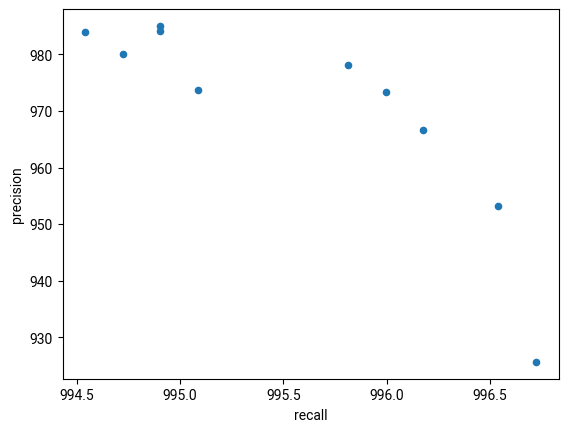

In [58]:
df_lmin.plot.scatter(x='recall', y='precision')
plt.savefig(f'docs/f1-score_lmin_{location}.png', bbox_inches='tight')

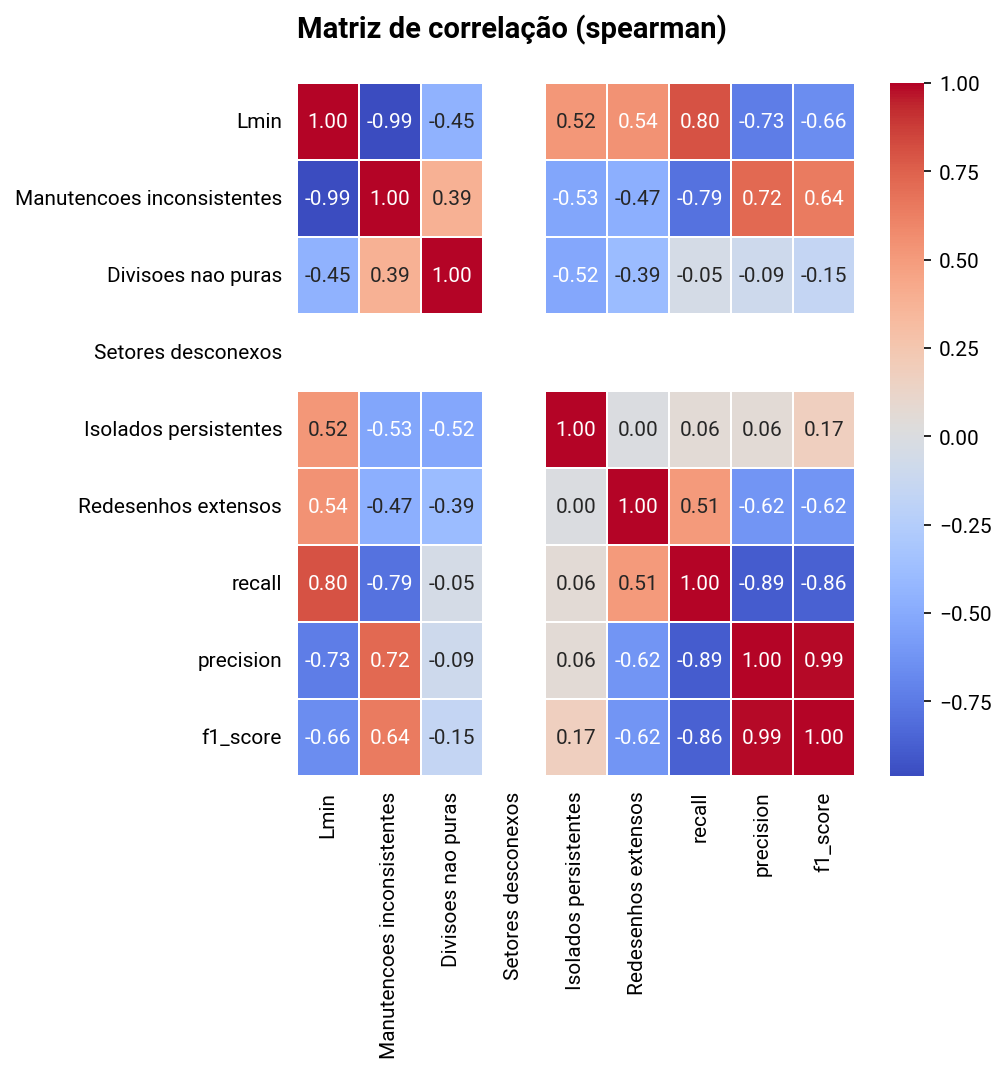

In [59]:
fig, ax = plt.subplots(1,1,figsize=(6, 6), dpi=150) # Adjust figure size as needed
sns.heatmap(df_lmin.corr(method='spearman'), annot=True, cmap='coolwarm', fmt=".2f", ax=ax, linewidth=.1, robust=True)
ax.set_title('Matriz de correlação (spearman)\n', fontsize=14, ha='left', x=0, weight='bold')
ax.tick_params(axis='y', color='white')
ax.tick_params(axis='x', color='white')
plt.savefig(f'docs/corr-spearman_lmin_{location}.png', bbox_inches='tight')
plt.show()

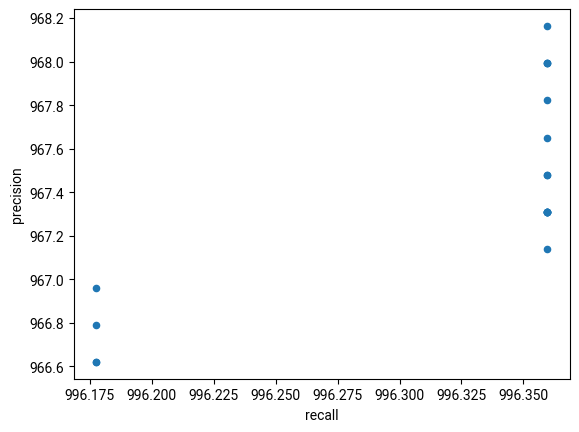

In [60]:
df_apr.plot.scatter(x='recall', y='precision')
plt.savefig(f'docs/f1-score_apr_{location}.png', bbox_inches='tight')

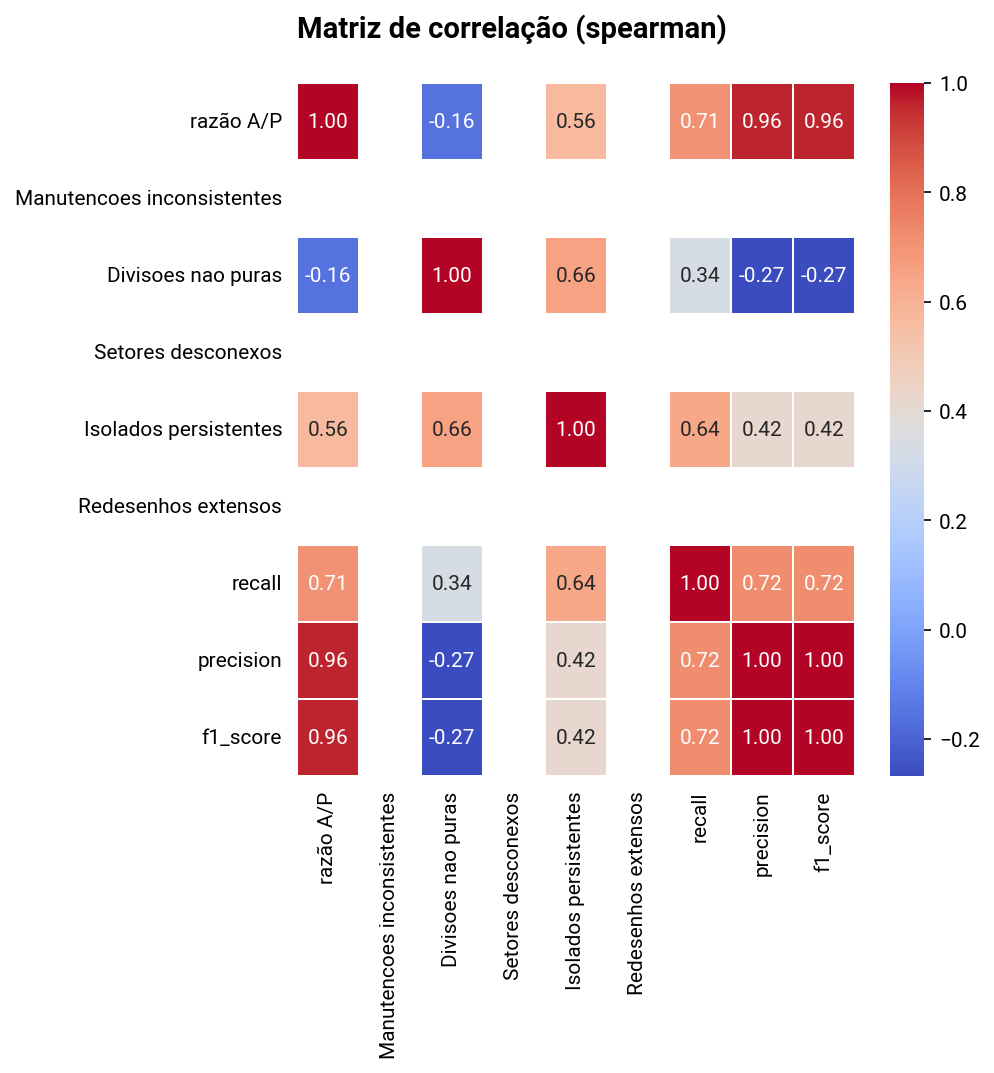

In [61]:
fig, ax = plt.subplots(1,1,figsize=(6, 6), dpi=150) # Adjust figure size as needed
sns.heatmap(df_apr.corr(method='spearman'), annot=True, cmap='coolwarm', fmt=".2f", ax=ax, linewidth=.1, robust=True)
ax.set_title('Matriz de correlação (spearman)\n', fontsize=14, ha='left', x=0, weight='bold')
ax.tick_params(axis='y', color='white')
ax.tick_params(axis='x', color='white')
plt.savefig(f'docs/corr-spearman_apr_{location}.png', bbox_inches='tight')
plt.show()